<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/PracticaLibros_AlvaroHernandez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exploración y recomendación no personalizada de libros**

* Asignatura: Sistemas de recomendación
* Profesor: Dra. Karla Olmos Sánchez
* Alumno: **Álvaro Hernández Jarquín**
* Matrícula: 263150
* Fecha de entrega: 17 de agosto de 2026




## 1. Objetivo de la práctica
Aplicar el proceso de exploración inicial de datos utilizado en la práctica de clase a un dominio distinto: la recomendación de libros. Al finalizar, el estudiante identificará usuarios, ítems e interacciones, revisará la calidad de los datos, analizará la actividad de los usuarios y la popularidad de los libros, y generará una lista de recomendaciones no personalizadas.

### Aprendizajes esperados
* Interpretar la estructura de un conjunto de datos para sistemas de recomendación.
* Distinguir entre información de los ítems e información de las interacciones.
* Diferenciar valoraciones explícitas e interacciones implícitas.
* Examinar valores faltantes, duplicados y tipos de datos.
* Calcular popularidad y calificación promedio de los libros.
* Reconocer las limitaciones de una recomendación basada en popularidad.

## 2. Conjunto de datos Book-Crossing
Book-Crossing contiene usuarios anonimizados, información de libros y valoraciones. La versión disponible en Kaggle reporta 278,858 usuarios, 1,149,780 valoraciones y 271,379 libros. Las calificaciones con valor 0 representan interacciones implícitas, mientras que los valores de 1 a 10 corresponden a valoraciones explícitas.

## 3. Preparación del entorno

### 3.2 Importar bibliotecas

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

### 3.3 Cargar los archivos

In [7]:
books = pd.read_csv(
    "/content/drive/MyDrive/MIAAD_05_SistemasDeRecomendacion/Books.csv",
    sep=",",
    encoding="latin-1",
    on_bad_lines="skip",
    low_memory=False
)

ratings = pd.read_csv(
    "/content/drive/MyDrive/MIAAD_05_SistemasDeRecomendacion/Ratings.csv",
    sep=",",
    encoding="latin-1",
    on_bad_lines="skip"
)

users = pd.read_csv(
    "/content/drive/MyDrive/MIAAD_05_SistemasDeRecomendacion/Users.csv",
    sep=",",
    encoding="latin-1",
    on_bad_lines="skip"
)

## 4. Actividad 1. Inspección inicial
Visualiza las primeras filas y revisa el tamaño de cada tabla.
Revisar nombres de columnas y tipos de datos

In [8]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [9]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [10]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [11]:
print(f"Books.csv. Filas: {books.shape[0]:,} y columnas: {books.shape[1]}")
print(f"Ratings.csv. Filas: {ratings.shape[0]:,} y columnas: {ratings.shape[1]}")
print(f"Users.csv. Filas: {users.shape[0]:,} y columnas: {users.shape[1]}")

Books.csv. Filas: 271,360 y columnas: 8
Ratings.csv. Filas: 1,149,780 y columnas: 3
Users.csv. Filas: 278,858 y columnas: 3


In [12]:
print("============Tipos de datos de Books.csv============")
print(books.info())
print()
print("============Tipos de datos de Ratings.csv============")
print(ratings.info())
print()
print("============Tipos de datos de Users.csv============")
print(users.info())


============Tipos de datos de Books.csv============
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB
None

============Tipos de datos de Ratings.csv============
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int

**Pregunta de análisis:** **¿Qué representa una fila en cada tabla? ¿Qué columnas permiten relacionarlas?**

La tabla `Books` tiene registro de libros que se venden en Amazon en cada fila; cada fila de la tabla `Ratings` es una valoración de un usuario sobre un libro; y,  en la tabla `Users`, en cada renglón se enlista un usuario, con su ubicación y edad. El **ISBN** relaciona la tabla `Books` con la tabla `Ratings`. La tabla `Ratings` se relaciona con el **User-ID** con la tabla `Users`. La tabla `Books` no se relaciona directamente con la tabla `Users`

## 6. Actividad 2. Calidad de los datos


### 6.1 Identifica valores faltantes


In [13]:
print("== Valores faltantes en Books.csv ==")
print(books.isna().sum())
print()
print("== Valores faltantes en Ratings.csv ==")
print(ratings.isna().sum())
print()
print("== Valores faltantes en Users.csv ==")
print(users.isna().sum())

== Valores faltantes en Books.csv ==
ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

== Valores faltantes en Ratings.csv ==
User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

== Valores faltantes en Users.csv ==
User-ID          0
Location         0
Age         110762
dtype: int64


### 6.2 Identifica registros duplicados


In [14]:
print(f"Registros duplicados en Books.csv: {books.duplicated().sum()}")
print(f"Registros duplicados en Ratings.csv: {ratings.duplicated().sum()}")
print(f"Registros duplicados en Users.csv: {users.duplicated().sum()}")

Registros duplicados en Books.csv: 0
Registros duplicados en Ratings.csv: 0
Registros duplicados en Users.csv: 0


### 6.3 Identifica interacciones usuario-libro repetidas

In [15]:
duplicadas = ratings.duplicated(subset=["User-ID", "ISBN"], keep=False)
print(f"Filas duplicadas: {duplicadas.sum()}")

Filas duplicadas: 0


**Pregunta de análisis:** **¿Qué decisiones tomarías si encuentras una misma pareja usuario-libro más de una vez?**

Primero hay que revisar cuántas parejas están duplicadas, si son pocas analizaría si puedo saber qué tipo de errores son, por ejemplo: un usuario que hizo dos revisiones del mismo libro, o que envío sin querer dos veces la misma revisión (como cuando se traba el botón de enviar). Si son iguales se puede eliminar una sin problema. Sin son diferentes, habría que decidir el criterio para seleccionar la que se queda: la más reciente, la más alta u otro.
De forma heurística, si son más de 10,000, que representa casi el 10% de los *ratings*, necesitaría hacer una análisis más profundo para estimar cuál fue la posible causa y hacer una previsión de cómo afectarían diferentes formas de eliminación de los duplicados.

## 7. Actividad 3. Valoraciones explícitas e implícitas
En este conjunto, Book-Rating = 0 representa una interacción implícita. Los valores de 1 a 10 son
calificaciones explícitas. Para comparar promedios de valoración se trabajará solamente con las
calificaciones explícitas.

In [16]:
print(ratings["Book-Rating"].value_counts().sort_index())

explicit_ratings = ratings[
    ratings["Book-Rating"].between(1, 10)
].copy()

implicit_ratings = ratings[
    ratings["Book-Rating"] == 0
].copy()

print(f"\nValoraciones explícitas: {len(explicit_ratings):,}")
print(f"Interacciones implícitas: {len(implicit_ratings):,}")

Book-Rating
0     716109
1       1770
2       2759
3       5996
4       8904
5      50974
6      36924
7      76457
8     103736
9      67541
10     78610
Name: count, dtype: int64

Valoraciones explícitas: 433,671
Interacciones implícitas: 716,109


**Pregunta de análisis:** **¿Por qué una valoración igual a cero no debe utilizarse para calcular el promedio de calificación de un libro?**

Por que significa que el usuario no ha realizado ninguna valoración del libro. Supongo que en el sistema de valoración (cuando el usuario entra a valorarlo) no se puede dejar en 0, así que solo hay posibilidad de que escoja, explícitamente, entre valores de 1 a 10. Así que el promedio de valoración se realizará entre los libros que hayan sido realizados, y así los valores 0 no afectarán en el cálculo del promedio.

## 8. Actividad 4. Calcula número de usuarios, número de libros e interacciones

Calcular la dispersión de la matriz usuario-ítem

In [17]:
num_users = users.shape[0]
num_books = books.shape[0]
num_interactions = explicit_ratings.shape[0]

possible_interactions = num_users * num_books
observed_percentage = (num_interactions / possible_interactions) * 100

print(f"Interacciones posibles: {possible_interactions:,}")
print("Porcentaje observado:", observed_percentage)

Interacciones posibles: 75,670,906,880
Porcentaje observado: 0.0005731013646865917


**Pregunta de análisis:** ¿Qué indica un porcentaje de interacciones observadas muy pequeño?

Que faltan muchos libros por ser recomendados por los usuarios registrados, lo cuál hará difícil que se pueda hacer un sistema de recomendación específico para cada usuario.

## 9. Actividad 5. Calcula la distribución de interacciones por usuario y realiza el histograma





In [18]:
interactions_user = explicit_ratings.groupby("User-ID", observed=False).size().sort_values(ascending=False)
print(f"Interaccions por usuario: {interactions_user}")

Interaccions por usuario: User-ID
11676     8524
98391     5802
153662    1969
189835    1906
23902     1395
          ... 
92537        1
92539        1
166822       1
32217        1
166793       1
Length: 77805, dtype: int64


In [19]:
print(interactions_user.describe())

count    77805.000000
mean         5.573819
std         44.001879
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max       8524.000000
dtype: float64


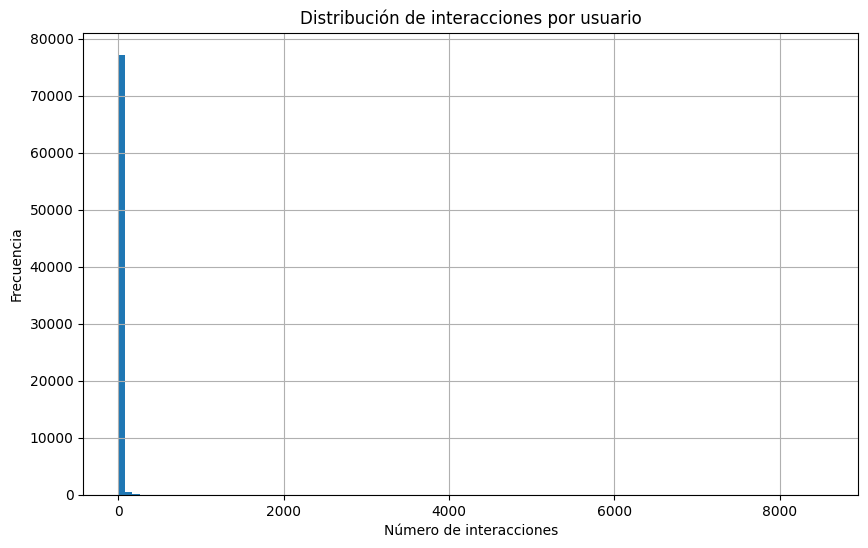

In [20]:
plt.figure(figsize=(10, 6))
interactions_user.hist(bins=100)
plt.xlabel("Número de interacciones")
plt.ylabel("Frecuencia")
plt.title("Distribución de interacciones por usuario")
plt.show()

In [21]:
usuarios_con_1 = (interactions_user == 1).sum()
print(f"Usuarios con 1 valoración: {usuarios_con_1:,}")
porcentaje_usuarios_con_1 = (usuarios_con_1 / len(interactions_user)) * 100
print(f"Porcentaje de usuarios con 1 valoración: {porcentaje_usuarios_con_1:.2f}%")

Usuarios con 1 valoración: 45,382
Porcentaje de usuarios con 1 valoración: 58.33%


**Pregunta de análisis:** **¿Todos los usuarios aportan una cantidad similar de información? ¿Cómo afectaría esto a una recomendación personalizada?**

No, hay dos usuarios que están por arriba de las 2,000 interacciones, y una gran cantidad (58.33%) que solo hizo una valoración. Con lo cual tenemos datos muy dispersos para generar una adecuada recomendación personalizada.

## 10. Actividad 6. Calcula la popularidad de los libros
La popularidad puede medirse mediante el número de interacciones totales o mediante el número de
usuarios distintos que interactuaron con cada libro. En esta tarea se utilizará el número de usuarios distintos.
Agregar la información descriptiva del libro





In [26]:
popularidad = explicit_ratings.groupby("ISBN", observed=False)['User-ID'].nunique().reset_index(name='rating_count')

popularidad_info = popularidad.merge(books[['ISBN', 'Book-Title', 'Book-Author']], on='ISBN')
print(popularidad_info.sort_values('rating_count', ascending=False)[['Book-Title', 'Book-Author', 'rating_count']].head(20))

                                               Book-Title      Book-Author  \
21945                           The Lovely Bones: A Novel     Alice Sebold   
117745                                        Wild Animus     Rich Shapero   
38819                                   The Da Vinci Code        Dan Brown   
18058                 The Red Tent (Bestselling Backlist)    Anita Diamant   
4131      Divine Secrets of the Ya-Ya Sisterhood: A Novel    Rebecca Wells   
68898   Harry Potter and the Sorcerer's Stone (Harry P...    J. K. Rowling   
12325                             The Secret Life of Bees    Sue Monk Kidd   
51799   Where the Heart Is (Oprah's Book Club (Paperba...     Billie Letts   
47986                                     A Painted House     John Grisham   
57625                           Girl with a Pearl Earring  Tracy Chevalier   
21893                          The Pilot's Wife : A Novel     Anita Shreve   
73422                                 Angels &amp; Demons       

**Pregunta de análisis:** **¿Por qué es preferible contar usuarios distintos en lugar de contar únicamente filas?**

Porque así es como puedo saber si un libro es más popular, conociendo la cantidad de personas diferentes que lo leyeron y valoraron. En caso de que usara los renglones, tomaría en cuenta los libros que pueden estar duplicados, aunque en esta base de datos no sea el caso.

## 11. Actividad 7. Calcula la calificación promedio




In [27]:
promedio = explicit_ratings.groupby("ISBN", observed=False)['Book-Rating'].mean().reset_index(name='rating_mean')

popularidad = popularidad.merge(promedio, on='ISBN')

print(popularidad.head())

           ISBN  rating_count  rating_mean
0    0330299891             1          6.0
1    0375404120             1          3.0
2    9022906116             1          7.0
3      #6612432             1          5.0
4  '9607092910'             1         10.0


In [33]:
popularidad_info2 = popularidad.merge(books[['ISBN', 'Book-Title', 'Book-Author']], on='ISBN')
print(popularidad_info2.sort_values('rating_mean', ascending=False).head(10))

              ISBN  rating_count  rating_mean  \
12      0001360469             1         10.0   
76698   0671737910             1         10.0   
76699   0671737929             1         10.0   
76709   0671738321             1         10.0   
25      0001900277             1         10.0   
26      0001935968             1         10.0   
33      0001953877             1         10.0   
35      0001981323             1         10.0   
40      0002005050             1         10.0   
149806  B00008RWPV             1         10.0   

                                               Book-Title       Book-Author  
12                                          Babe Dressing     Mandy Stanley  
76698                        PENNY WHISTLE HALLOWEEN BOOK   Meredith Brokaw  
76699                         Penny Whistle Party Planner   Meredith Brokaw  
76709   THEY CAN KILL YOU BUT THEY CAN'T EAT YOU: LESS...        Dawn Steel  
25                      Glue (First Facts - First Skills)     Harriet 


**Pregunta de análisis:** **¿Por qué una lista ordenada solamente por promedio puede colocar en primer lugar a libros con muy pocas valoraciones?**

Porque el promedio se ve afectado por el tamaño de la muestra. Debido a que hay muchos libros con una sola reseña, esta reseña es el promedio total. En cambio en libros con muchas reseñas el promedio se ve afectado por todas. Quizás se podría combinar el promedio con el número de valoraciones que tuvo.

## 12. Actividad 8. Recomendación no personalizada
Construye una lista de diez libros bien evaluados que tengan un número mínimo de valoraciones explícitas. El
umbral puede ajustarse después de observar la distribución del conjunto.



Si no aparecen suficientes libros: Reduce gradualmente minimum_ratings a 30, 20 o 10. Explica en el
reporte por qué elegiste el umbral final.

In [40]:
minimum_ratings = [10, 20, 30, 40, 50]

for umbral in minimum_ratings:
  count = (popularidad_info['rating_count'] >= umbral).sum()
  print(f"\n=== Umbral mínimo: {umbral} valoraciones: {count} libros===")
  recomendaciones = popularidad_info2[popularidad_info2['rating_count'] >= umbral].sort_values('rating_mean', ascending=False).head(10)
  print(recomendaciones[['Book-Title', 'Book-Author', 'rating_count', 'rating_mean']])


=== Umbral mínimo: 10 valoraciones: 5444 libros===
                                               Book-Title  \
133072   Postmarked Yesteryear: 30 Rare Holiday Postcards   
103897                       Dilbert: A Book of Postcards   
46490   Harry Potter and the Chamber of Secrets Postca...   
21229             Kiss of the Night (A Dark-Hunter Novel)   
41012                                           The Lorax   
40956   Fox in Socks (I Can Read It All by Myself Begi...   
2719                                      The Giving Tree   
17501   Route 66 Postcards: Greetings from the Mother ...   
71460      The Two Towers (The Lord of the Rings, Part 2)   
142498  Maus 1. Mein Vater kotzt Geschichte aus. Die G...   

                       Book-Author  rating_count  rating_mean  
133072  Pamela E. Apkarian-Russell            11    10.000000  
103897                 Scott Adams            13     9.923077  
46490                J. K. Rowling            23     9.869565  
21229             Sh

## 13. Actividad 9. Mejora opcional: promedio ponderado
Para evitar que un libro con pocas valoraciones domine la lista, calcula una puntuación ponderada que
combine el promedio del libro con el promedio global.

In [41]:
C = explicit_ratings["Book-Rating"].mean()
m = 50

book_statistics = popularidad_info2.copy()

book_statistics["weighted_score"] = (
    (book_statistics["rating_count"] /
     (book_statistics["rating_count"] + m))
    * book_statistics["rating_mean"]
        +
    (m /
     (book_statistics["rating_count"] + m))
    * C
)

weighted_recommendations = (
    book_statistics[
        book_statistics["rating_count"] >= m
    ]
    .sort_values("weighted_score", ascending=False)
    .head(10)
)

display(
    weighted_recommendations[
        [
            "Book-Title",
            "Book-Author",
            "rating_count",
            "rating_mean",
            "weighted_score"
        ]
    ]
)

,Book-Title,Book-Author,rating_count,rating_mean,weighted_score
46135,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,137,9.262774,8.818467
68898,Harry Potter and the Sorcerer's Stone (Harry P...,J. K. Rowling,313,8.939297,8.754968
46425,Harry Potter and the Order of the Phoenix (Boo...,J. K. Rowling,206,9.033981,8.754115
24538,"The Return of the King (The Lord of the Rings,...",J.R.R. TOLKIEN,77,9.402597,8.693333
50045,To Kill a Mockingbird,Harper Lee,214,8.943925,8.689596
46125,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,133,9.082707,8.677887
46124,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,141,9.035461,8.659965
68897,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,119,8.983193,8.574280
24537,"The Two Towers (The Lord of the Rings, Part 2)",J.R.R. TOLKIEN,83,9.120482,8.549273
46019,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,126,8.920635,8.545757


**Pregunta de análisis:** ¿Qué diferencias observas entre la lista ordenada por promedio simple y la lista ordenada por promedio ponderado?

En la lista de promedio simple los libros que tienen pocos votos pero un promedio alto, como El principito, tienen posiciones altas. En la lista de promedio ponderado los libros con pocas valoraciones bajan y los que tienen muchas y con buen promedio mejoran su posición o se mantienen. Pienso que la lista de promedio ponderado es más certera para recomendar porque toma en cuenta ambas características: la calificación y las valoraciones recibidas.

## 15. Preguntas de reflexión final
1. ¿La lista obtenida es una recomendación personalizada? Explica por qué.

Para mi versión final, tomo 50 como el umbral idóneo, quita los libros que tienen pocas valoraciones. Esta lista, no es una recomendación personalizada ya que es la misma lista que le aparecerá a todos los usuarios. Para que sea una lista personalizada, debería basarse en información proveniente del usuario a quien se le recomienda.

2. ¿Qué usuarios recibirían exactamente la misma lista?


Todos los usuarios que soliciten una recomendación. Creo que se les presentaría en el momento de acceder a Amazon, a todos los usuarios se les pondría la lista de estos libros.

3. ¿Qué diferencia existe entre un libro popular y un libro bien evaluado?


Como trabajamos la popularidad en este ejercicio, se refería a la cantidad de valoraciones que se realizaron sobre determinado libro. Si fue bien evaluado depende de la calificación que obtuvo en esa valoración o el promedio de esas evaluaciones.

4. ¿Qué efecto tienen las calificaciones implícitas con valor cero?


Si las consideramos en el promedio de la calificación, afectarían negativamente ese valor, aún cuando no fueron realizadas.

5. ¿Qué problema enfrentan los libros nuevos o con pocas valoraciones?


No serán considerados en el sistema de evaluación de la misma forma que los que ya han sido evaluados, así que este sistema tiene el sesgo de la antigüedad.

6. ¿Qué sesgo puede producir recomendar principalmente los libros más populares?


Que no se tomarán en cuenta los poco valorados, lo que puede crear una cámara de eco, nadie valorará los que no hayan sido valorados y se seguirán recomendando los valorados. Otro sesgo es, como se explicó en la pregunta pasada, que los libros nuevos difícilmente entrarán en este bucle.

7. ¿Qué información sería necesaria para generar recomendaciones distintas para cada usuario?


Mayor información explícita de cada usuario respecto a su interacción con los libros.

8. ¿Qué limitaciones encontraste en la calidad o estructura de Book-Crossing?


Considera pocas variables y depende totalmente de las valoraciones de los usuarios.

## 17. Fuente del conjunto de datos
Book Recommendation Dataset. Kaggle. https://www.kaggle.com/datasets/arashnic/book-recommendation-dataset


El conjunto fue recopilado originalmente por Cai-Nicolas Ziegler a partir de la comunidad Book-Crossing. Para
trabajos académicos, revisa la sección de reconocimiento y citación incluida en la página del conjunto de
datos.